In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('mars-2014-complete.csv', sep=';', encoding='latin1')
for col in df.columns:
    if 'unnamed' in col.lower():
        del df[col]
col_to_remove = ['hc', 'nox', 'hcnox', 'ptcl', 'co_typ_1', 'date_maj']
df.drop(col_to_remove, axis=1, inplace=True)
df.dropna(inplace=True)
df['gamme'] = df['gamme'].replace({
    'MOY-INFER': 'MOYENNE',
    'MOY-SUPER': 'MOYENNE',
    'MOY-INFERIEURE': 'MOYENNE',
    'LUXE': 'SUPERIEURE',
    'ECONOMIQUE': 'INFERIEURE',
})
df['Carrosserie'] = df['Carrosserie'].replace({
    'TS TERRAINS/CHEMINS': '4x4',
    'MINISPACE': 'MINI',
    'MONOSPACE COMPACT': 'MONO',
    'MONOSPACE': 'MONO',
    'MINIBUS': 'COMBI',
    'COMBISPCACE': 'COMBISPACE'
})

def replace_commato_dot(x):
    return x.replace(',', '.')
df['conso_exurb'] = df['conso_exurb'].apply(replace_commato_dot).astype(float)
df['conso_urb'] = df['conso_urb'].apply(replace_commato_dot).astype(float)
df['conso_mixte'] = df['conso_mixte'].apply(replace_commato_dot).astype(float)
df.to_csv('mars-2014-complete-cleaned.csv', index=False)

print(df.shape)
print(df.columns)

(54974, 20)
Index(['lib_mrq', 'lib_mod_doss', 'lib_mod', 'dscom', 'cnit', 'tvv', 'cod_cbr',
       'hybride', 'puiss_admin_98', 'puiss_max', 'typ_boite_nb_rapp',
       'conso_urb', 'conso_exurb', 'conso_mixte', 'co2', 'masse_ordma_min',
       'masse_ordma_max', 'champ_v9', 'Carrosserie', 'gamme'],
      dtype='object')


<Axes: xlabel='cod_cbr'>

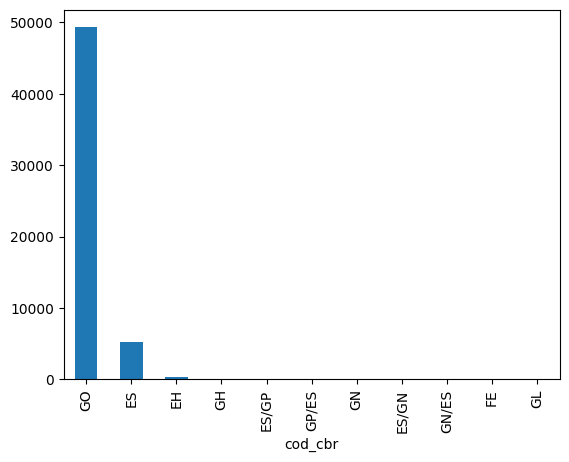

In [57]:
df.cod_cbr.value_counts().plot(kind='bar')

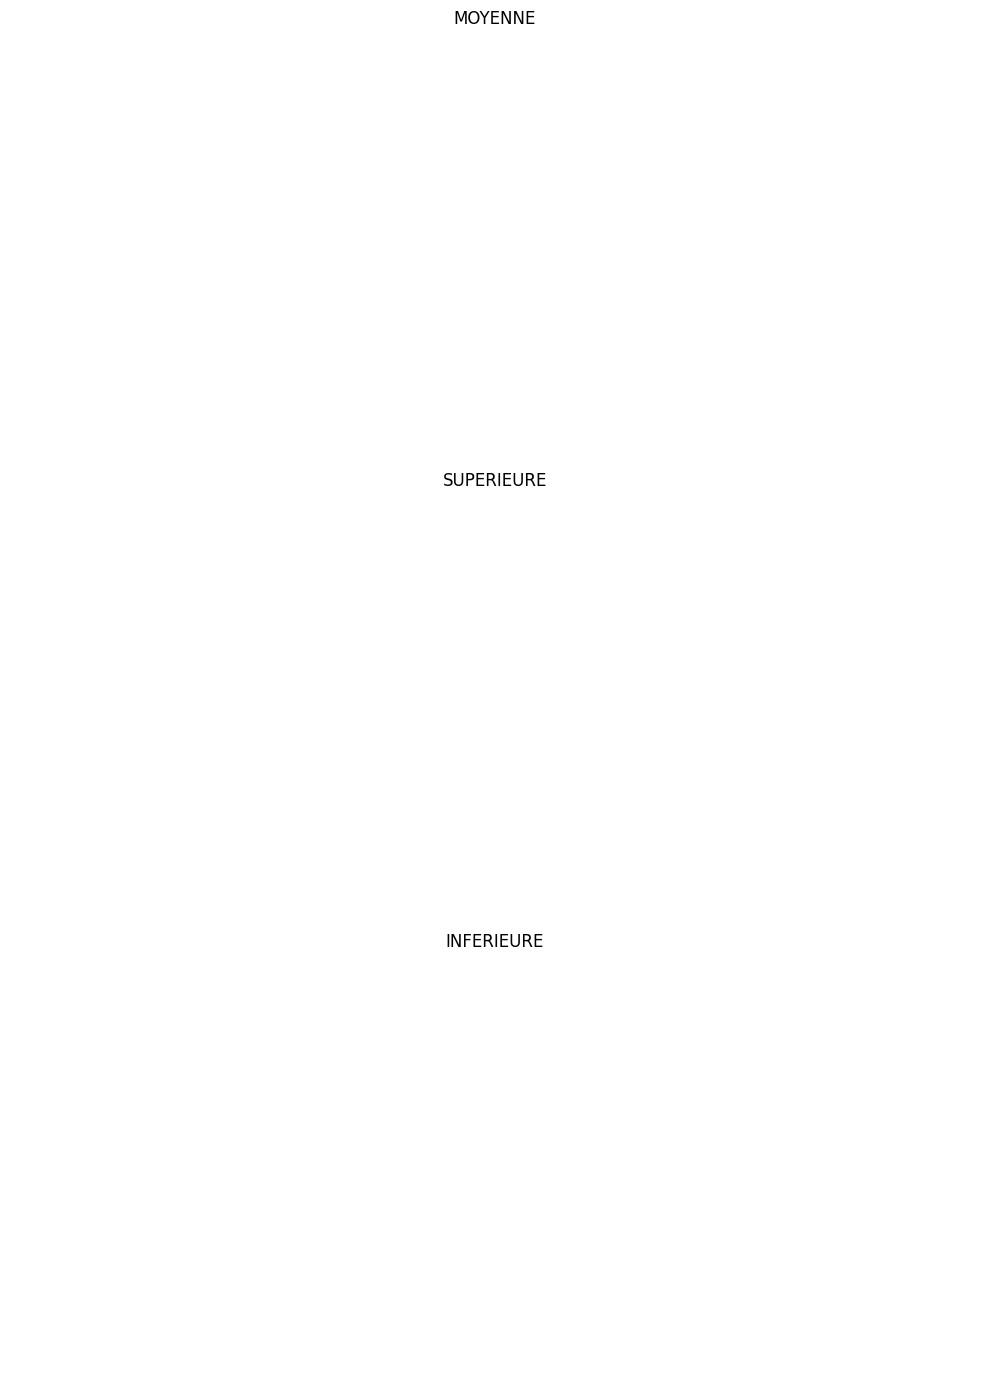

In [39]:
group_by = 'gamme'
num = 'conso_mixte'
n = df[group_by].nunique()
palette = sns.color_palette('husl', n)
fig, ax = plt.subplots(nrows=n, figsize=(10, 14))

# sort dataframe by average co2 per carrosserie
carrosseries = df.groupby(group_by)[num].median().sort_values(ascending=False)

for i, carrosserie in enumerate(carrosseries.index):
    
    # filter
    subset = df[df[group_by] == carrosserie]
    
    # plot
    sns.kdeplot(
        subset[num],
        ax=ax[i],
        color=palette[i],
        label=carrosserie,
        fill=True
    )
    
    # remove y axis
    ax[i].set_ylabel('')
    ax[i].set_xlabel(num)
    ax[i].set_title(carrosserie)
    ax[i].set_xlim(60, 400)
    ax[i].set_ylim(0, 0.03)
    ax[i].set_axis_off()


plt.tight_layout()
plt.savefig('ridgeplot.png')
plt.show()

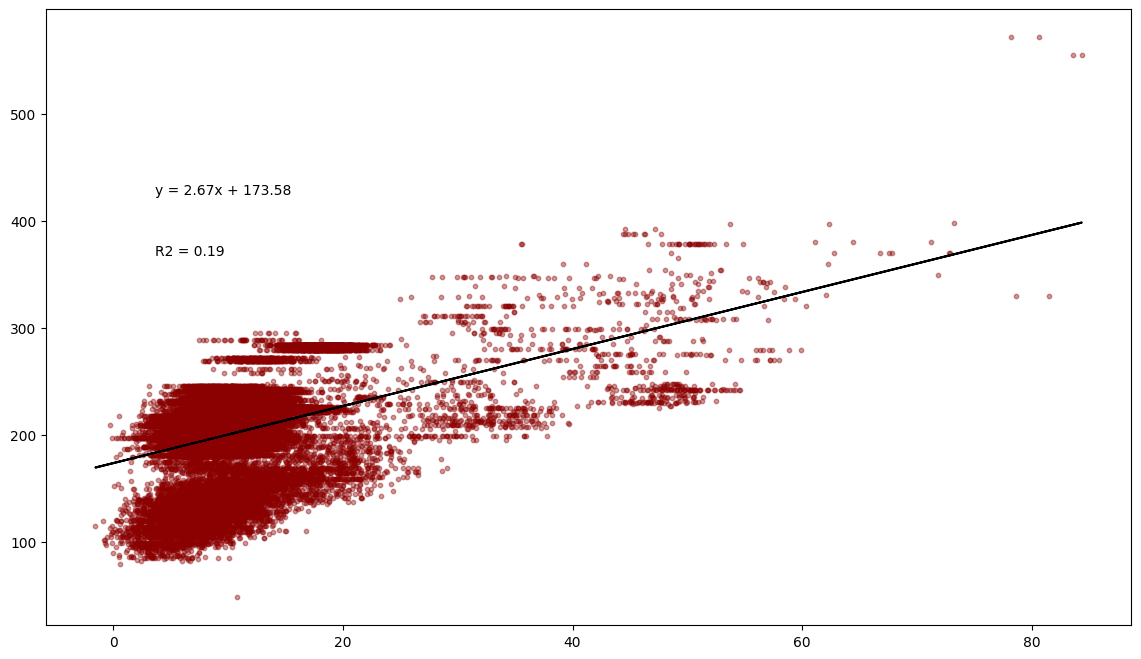

In [81]:
data = df.copy()
x = 'puiss_admin_98'
y = 'co2'
data[x] = data[x] + np.random.normal(0, 2, data.shape[0])
#data[y] = data[y] + np.random.normal(0, 1, data.shape[0])


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 8))
ax.scatter(
    data[x],
    data[y],
    color='darkred',
    alpha=0.4,
    s=10
)

# fit linear reg
x = data[x].values
y = data[y].values
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='black')

# print coef
ax.text(0.1, 0.7, f'y = {m:.2f}x + {b:.2f}', transform=ax.transAxes)

# print R2
r2 = np.corrcoef(x, y)[0, 1] ** 2
ax.text(0.1, 0.6, f'R2 = {r2:.2f}', transform=ax.transAxes)


    
plt.show()

(0.0, 10.0)

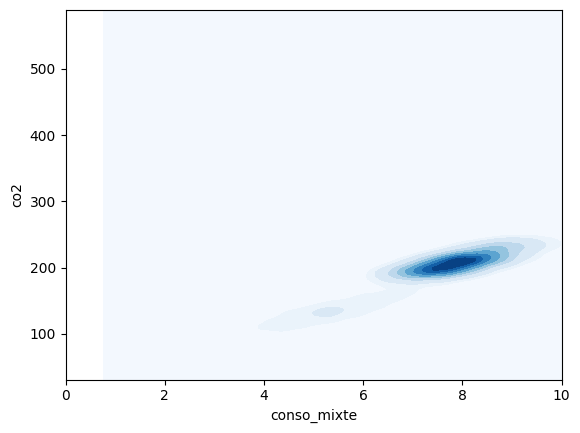

In [82]:
data = df.copy()
x = 'conso_mixte'
y = 'co2'
data[x] = data[x] + np.random.normal(0, 0.5, data.shape[0])
data[y] = data[y] + np.random.normal(0, 2, data.shape[0])

sns.kdeplot(x=data[x], y=data[y], cmap="Blues", fill=True, thresh=0)
plt.xlim(0, 10)